<a href="https://colab.research.google.com/github/AgathaKarenne32/Trabalhho_Final_IA/blob/main/Trabalho_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CÉLULA 1: Instalação e Importações
!pip install scikit-fuzzy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
print("Célula 1 executada com sucesso! Bibliotecas importadas.")

Célula 1 executada com sucesso! Bibliotecas importadas.


Base de dados criada com 200 registros.


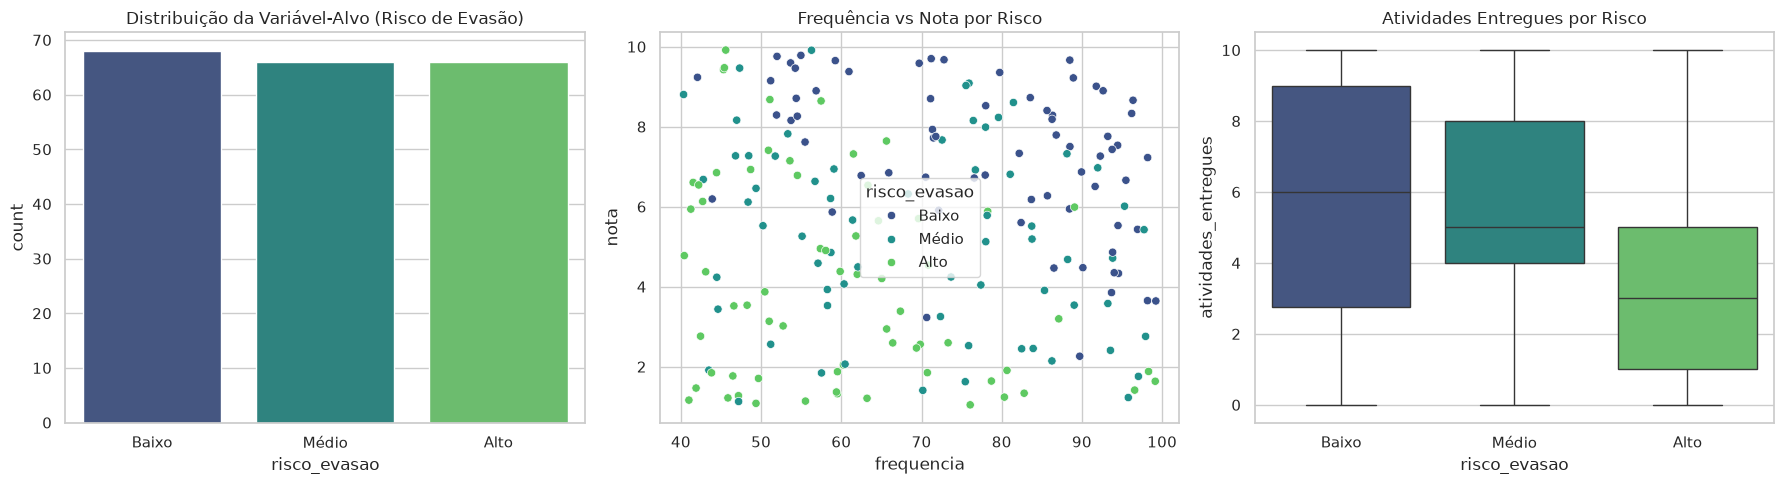

In [2]:
# CÉLULA 2: Simulação de Dados e EDA
np.random.seed(42)
n_registros = 200

# Variáveis de entrada simuladas de forma coerente
frequencia = np.random.uniform(40, 100, n_registros)
nota = np.random.uniform(1.0, 10.0, n_registros)
atividades = np.random.randint(0, 11, n_registros)
acessos = np.random.randint(5, 150, n_registros)
reprovacoes = np.random.randint(0, 4, n_registros)

# Criando uma lógica oculta (pontuação de desempenho) para gerar o target
# Quanto menor a pontuação, MAIOR o risco de evasão
pontuacao = (frequencia * 0.4) + (nota * 4) + (atividades * 2) + (acessos * 0.1) - (reprovacoes * 10)

# Definindo os limiares para a variável-alvo: Risco Baixo, Médio e Alto
limite_inferior = np.percentile(pontuacao, 33)
limite_superior = np.percentile(pontuacao, 66)

risco_evasao = []
for p in pontuacao:
    if p < limite_inferior:
        risco_evasao.append('Alto')
    elif p < limite_superior:
        risco_evasao.append('Médio')
    else:
        risco_evasao.append('Baixo')

# Criação do DataFrame
df = pd.DataFrame({
    'frequencia': frequencia,
    'nota': nota,
    'atividades_entregues': atividades,
    'acessos_ava': acessos,
    'reprovacoes_anteriores': reprovacoes,
    'risco_evasao': risco_evasao
})

print(f"Base de dados criada com {len(df)} registros.")

# EDA: Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='risco_evasao', order=['Baixo', 'Médio', 'Alto'], palette='viridis', ax=axes[0])
axes[0].set_title('Distribuição da Variável-Alvo (Risco de Evasão)')

sns.scatterplot(data=df, x='frequencia', y='nota', hue='risco_evasao', palette='viridis', ax=axes[1])
axes[1].set_title('Frequência vs Nota por Risco')

sns.boxplot(data=df, x='risco_evasao', y='atividades_entregues', order=['Baixo', 'Médio', 'Alto'], palette='viridis', ax=axes[2])
axes[2].set_title('Atividades Entregues por Risco')

plt.tight_layout()
plt.show()

--- AVALIAÇÃO DO MODELO DE MACHINE LEARNING ---
Acurácia: 0.65

Relatório de Classificação (Precision, Recall, F1):
              precision    recall  f1-score   support

        Alto       0.73      0.80      0.76        20
       Baixo       0.71      0.75      0.73        20
       Médio       0.47      0.40      0.43        20

    accuracy                           0.65        60
   macro avg       0.64      0.65      0.64        60
weighted avg       0.64      0.65      0.64        60



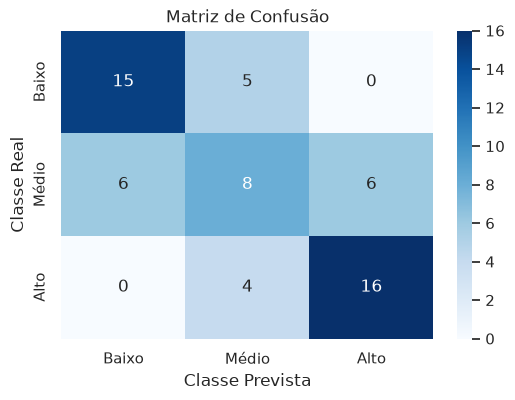

In [3]:
# CÉLULA 3: Machine Learning - Árvore de Decisão
X = df[['frequencia', 'nota', 'atividades_entregues', 'acessos_ava', 'reprovacoes_anteriores']]
y = df['risco_evasao']

# Separação Treino e Teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Treinamento da Árvore de Decisão
# max_depth=4 para evitar overfitting e manter interpretabilidade
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Predições de Classe e Probabilidade
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test) # Será usado na Abordagem B

# Métricas de Avaliação
acuracia = accuracy_score(y_test, y_pred)
matriz_conf = confusion_matrix(y_test, y_pred, labels=['Baixo', 'Médio', 'Alto'])
relatorio = classification_report(y_test, y_pred)

print(f"--- AVALIAÇÃO DO MODELO DE MACHINE LEARNING ---")
print(f"Acurácia: {acuracia:.2f}\n")
print("Relatório de Classificação (Precision, Recall, F1):")
print(relatorio)

# Plot da Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title('Matriz de Confusão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

--- RESULTADO DA ABORDAGEM A: COMPARAÇÃO ---
Taxa de Concordância entre Árvore de Decisão e Sistema Fuzzy Autônomo: 45.00%



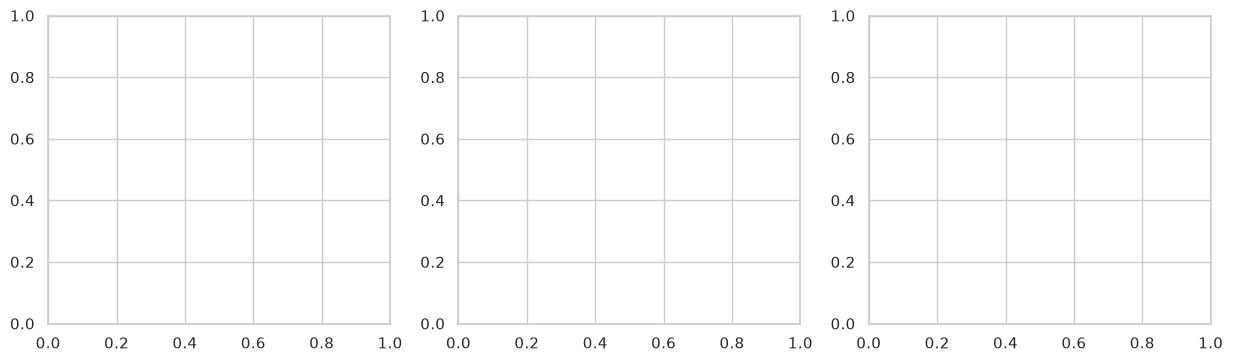

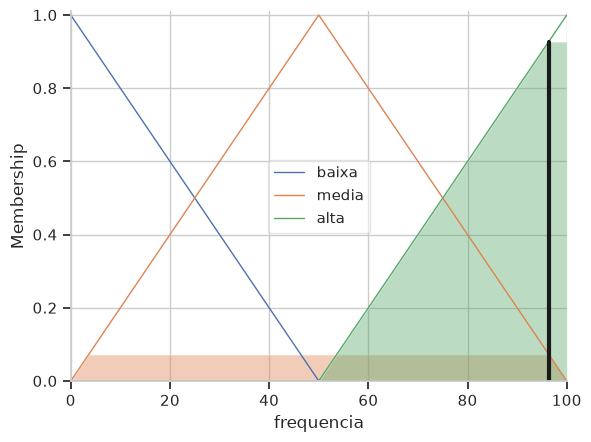

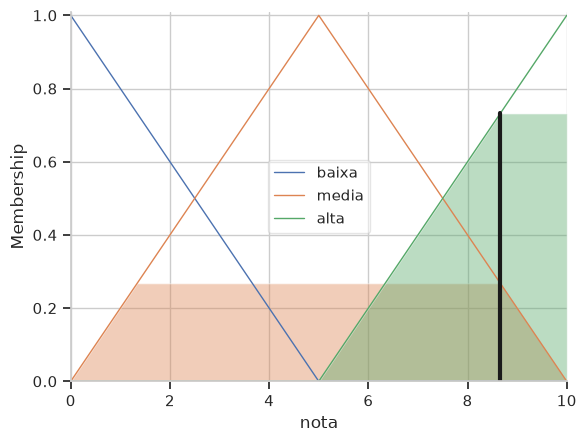

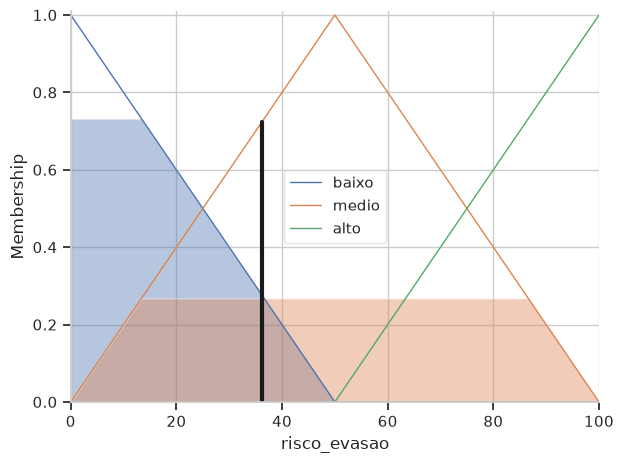

In [4]:
# CÉLULA 4: Abordagem A - Sistema Fuzzy Autônomo e Comparação

# 1. Definição das Variáveis de Entrada e Saída
freq_A = ctrl.Antecedent(np.arange(0, 101, 1), 'frequencia')
nota_A = ctrl.Antecedent(np.arange(0, 11, 1), 'nota')
risco_A = ctrl.Consequent(np.arange(0, 101, 1), 'risco_evasao')

# 2. Funções de Pertinência (3 termos linguísticos cada)
freq_A.automf(3, names=['baixa', 'media', 'alta'])
nota_A.automf(3, names=['baixa', 'media', 'alta'])
risco_A.automf(3, names=['baixo', 'medio', 'alto'])

# 3. Regras Fuzzy (Mínimo de 6 regras lógicas)
regra1_A = ctrl.Rule(freq_A['baixa'] & nota_A['baixa'], risco_A['alto'])
regra2_A = ctrl.Rule(freq_A['media'] & nota_A['baixa'], risco_A['alto'])
regra3_A = ctrl.Rule(freq_A['baixa'] & nota_A['media'], risco_A['alto'])
regra4_A = ctrl.Rule(freq_A['media'] & nota_A['media'], risco_A['medio'])
regra5_A = ctrl.Rule(freq_A['alta'] & nota_A['alta'], risco_A['baixo'])
regra6_A = ctrl.Rule(freq_A['media'] & nota_A['alta'], risco_A['baixo'])
regra7_A = ctrl.Rule(freq_A['alta'] & nota_A['media'], risco_A['medio'])

# 4. Criação do Controlador e Simulação
ctrl_risco_A = ctrl.ControlSystem([regra1_A, regra2_A, regra3_A, regra4_A, regra5_A, regra6_A, regra7_A])
simulador_A = ctrl.ControlSystemSimulation(ctrl_risco_A)

# 5. Comparação com o Machine Learning (Aplicando Fuzzy na base de teste)
fuzzy_classes_A = []

for idx, row in X_test.iterrows():
    simulador_A.input['frequencia'] = row['frequencia']
    simulador_A.input['nota'] = row['nota']
    try:
        simulador_A.compute()
        score_fuzzy = simulador_A.output['risco_evasao']
        # Convertendo o score numérico fuzzy de volta para classe nominal para comparar
        if score_fuzzy < 40:
            fuzzy_classes_A.append('Baixo')
        elif score_fuzzy < 70:
            fuzzy_classes_A.append('Médio')
        else:
            fuzzy_classes_A.append('Alto')
    except:
        fuzzy_classes_A.append('Desconhecido') # Fallback se nenhuma regra ativar

# Calculando a concordância entre DT e Fuzzy A
concordancia = np.mean(np.array(y_pred) == np.array(fuzzy_classes_A)) * 100

print(f"--- RESULTADO DA ABORDAGEM A: COMPARAÇÃO ---")
print(f"Taxa de Concordância entre Árvore de Decisão e Sistema Fuzzy Autônomo: {concordancia:.2f}%\n")

# Visualização das funções de pertinência
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
freq_A.view(sim=simulador_A, ax=axes[0])
nota_A.view(sim=simulador_A, ax=axes[1])
risco_A.view(sim=simulador_A, ax=axes[2])
plt.tight_layout()
plt.show()

=== RESULTADO DA COMPARAÇÃO (ABORDAGEM A) ===
Parâmetros: Frequência 60%, Nota 5.5
-> Decisão Machine Learning: Risco Médio
-> Decisão Sistema Fuzzy...: Risco Médio (Score: 49.75/100)
>> Análise: Os sistemas CONCORDAM sobre o nível de risco deste aluno.
---------------------------------------------


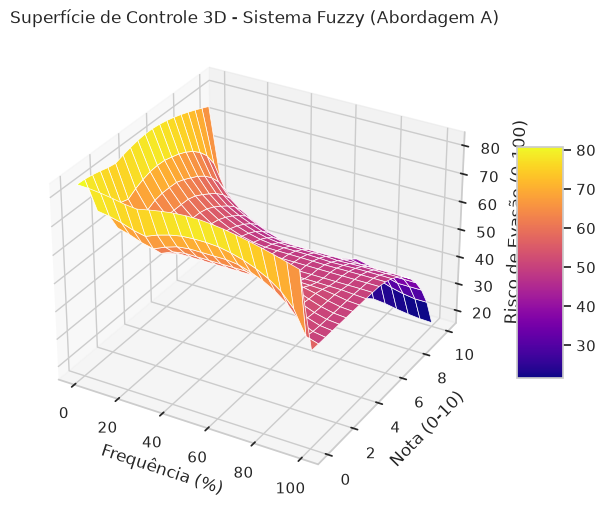

In [5]:
# CÉLULA 6: Função Interativa e Gráfico 3D para Abordagem A

def consultar_aluno_comparacao(frequencia_val, nota_val, atividades, acessos, reprovacoes):
    """
    Abordagem A: Compara a decisão pura do Machine Learning com a decisão pura do Fuzzy
    """
    # 1. Predição do Machine Learning (Árvore de Decisão)
    dados_aluno = pd.DataFrame([[frequencia_val, nota_val, atividades, acessos, reprovacoes]],
                               columns=X_train.columns)
    predicao_ml = clf.predict(dados_aluno)[0]

    # 2. Predição do Sistema Fuzzy (Autônomo)
    simulador_A.input['frequencia'] = frequencia_val
    simulador_A.input['nota'] = nota_val
    simulador_A.compute()
    score_fuzzy = simulador_A.output['risco_evasao']

    # Traduzindo o score fuzzy para classe nominal para fins de comparação
    if score_fuzzy < 40:
        classe_fuzzy = 'Baixo'
    elif score_fuzzy < 70:
        classe_fuzzy = 'Médio'
    else:
        classe_fuzzy = 'Alto'

    print(f"=== RESULTADO DA COMPARAÇÃO (ABORDAGEM A) ===")
    print(f"Parâmetros: Frequência {frequencia_val}%, Nota {nota_val}")
    print(f"-> Decisão Machine Learning: Risco {predicao_ml}")
    print(f"-> Decisão Sistema Fuzzy...: Risco {classe_fuzzy} (Score: {score_fuzzy:.2f}/100)")

    if predicao_ml == classe_fuzzy:
        print(">> Análise: Os sistemas CONCORDAM sobre o nível de risco deste aluno.")
    else:
        print(">> Análise: Os sistemas DIVERGEM. O ML considerou variáveis adicionais (reprovações, acessos) que o Fuzzy clássico ignorou.")
    print("-" * 45)

# Testando a função com um aluno fictício
consultar_aluno_comparacao(60, 5.5, atividades=4, acessos=40, reprovacoes=1)

# Plotando a Superfície 3D da Abordagem A
x_freq, y_nota = np.meshgrid(np.linspace(0, 100, 20), np.linspace(0, 10, 20))
z_risco = np.zeros_like(x_freq)

for i in range(20):
    for j in range(20):
        simulador_A.input['frequencia'] = x_freq[i, j]
        simulador_A.input['nota'] = y_nota[i, j]
        try:
            simulador_A.compute()
            z_risco[i, j] = simulador_A.output['risco_evasao']
        except:
            z_risco[i, j] = 50 # Default para áreas sem regras ativadas

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_freq, y_nota, z_risco, cmap='plasma', linewidth=0.5, antialiased=True)
ax.set_xlabel('Frequência (%)')
ax.set_ylabel('Nota (0-10)')
ax.set_zlabel('Risco de Evasão (0-100)')
ax.set_title('Superfície de Controle 3D - Sistema Fuzzy (Abordagem A)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()